# Plot Simulation Results — Models 1, 2, 3

Loads a `.pkl` trajectory file produced by `01_run_simulation.ipynb` and generates:

- **A** Time-course trajectories (RasGTP + Bound SOS)
- **B** RasGTP count distributions
- **C** SOS occupancy distributions
- **D** RasGTP distributions conditioned on SOS occupancy 

Reproduces supplemental figures S2-S4 in manuscript


In [37]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


## Load trajectory data

In [38]:
MODEL = "Model3"   # "Model1", "Model2", "Model3"

with open(MODEL + '_traj.pkl', 'rb') as f:
    pl = pickle.load(f)

pval = pl['pval']
traj = pl['traj']
print(f"Loaded {MODEL}: {len(traj)} trajectories, [SOS] = {pval} nM")


Loaded Model3: 3 trajectories, [SOS] = [1, 5, 10] nM


## A — Time-course trajectories

RasGTP (blue) and Bound SOS (orange) vs time for each SOS concentration.


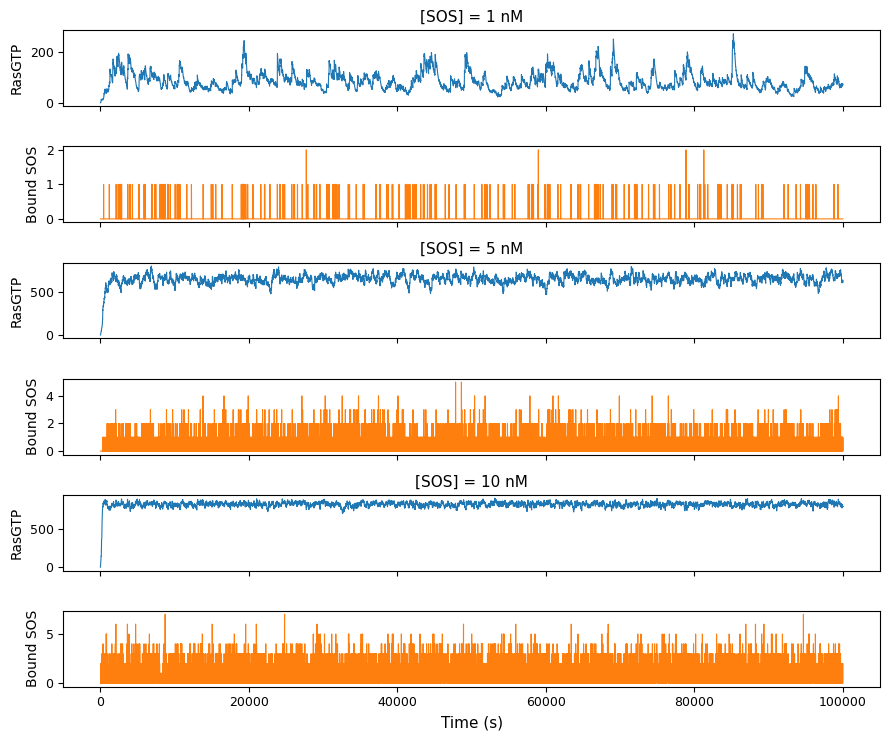

In [39]:
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
obs_labels  = {'totalRasGTP': 'RasGTP', 'totalBoundRas': 'Bound SOS'}
obs_keys    = list(obs_labels.keys())

n = len(traj)
fig, axes = plt.subplots(n * 2, 1, figsize=(9, 2.5 * n), sharex=False)

for i, (t, sos) in enumerate(zip(traj, pval)):
    for j, key in enumerate(obs_keys):
        ax = axes[i * 2 + j]
        ax.plot(t['time'], t[key], color=color_cycle[j], lw=0.8)
        ax.set_ylabel(obs_labels[key], fontsize=10)
        ax.tick_params(labelsize=9)
        if j == 0:
            ax.set_title(f'[SOS] = {sos} nM', fontsize=11)
        if i == n - 1 and j == 1:
            ax.set_xlabel('Time (s)', fontsize=11)
        else:
            ax.set_xticklabels([])

plt.tight_layout()
plt.show()


## B — RasGTP count distributions

Normalized histogram of RasGTP counts across the full trajectory.


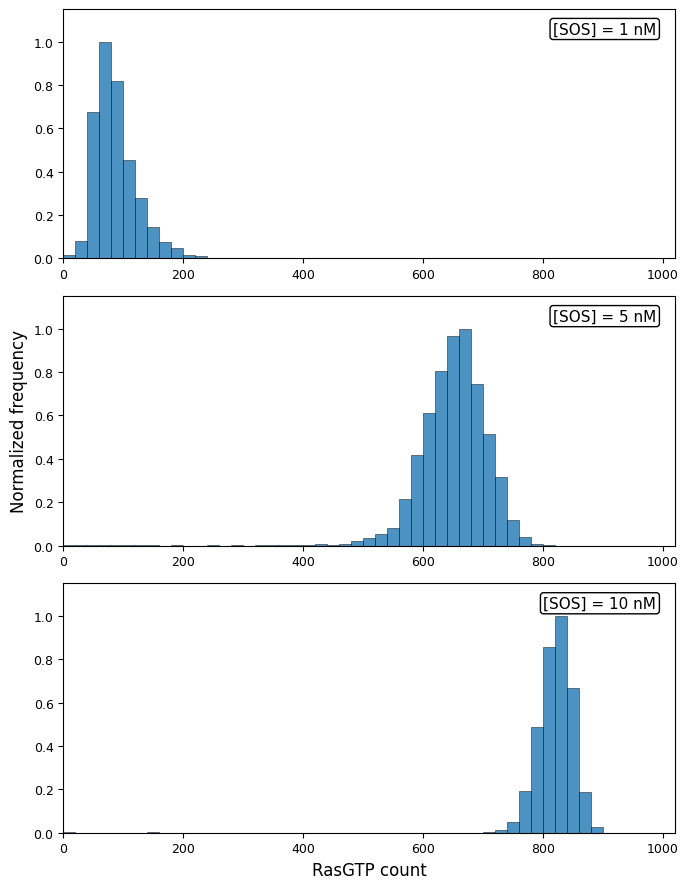

In [40]:
fig, axes = plt.subplots(len(traj), 1, figsize=(7, 3 * len(traj)))
if len(traj) == 1:
    axes = [axes]

for j, (t, sos) in enumerate(zip(traj, pval)):
    ax   = axes[j]
    data = np.asarray(t['totalRasGTP'])
    counts, edges = np.histogram(data, bins=50, range=(0, 1000))
    counts = counts / counts.max()
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.bar(centers, counts, width=edges[1]-edges[0],
           color='C0', edgecolor='black', linewidth=0.4, alpha=0.8)
    ax.set_xlim(0, 1020)
    ax.set_ylim(0, 1.15)
    ax.text(0.97, 0.95, f'[SOS] = {sos} nM', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black'))
    ax.tick_params(labelsize=9)
    if j == len(traj) - 1:
        ax.set_xlabel('RasGTP count', fontsize=12)
    if j == len(traj) // 2:
        ax.set_ylabel('Normalized frequency', fontsize=12)

plt.tight_layout()
plt.show()


## C — SOS occupancy distributions

Distribution of the number of SOS molecules simultaneously bound in the corral.


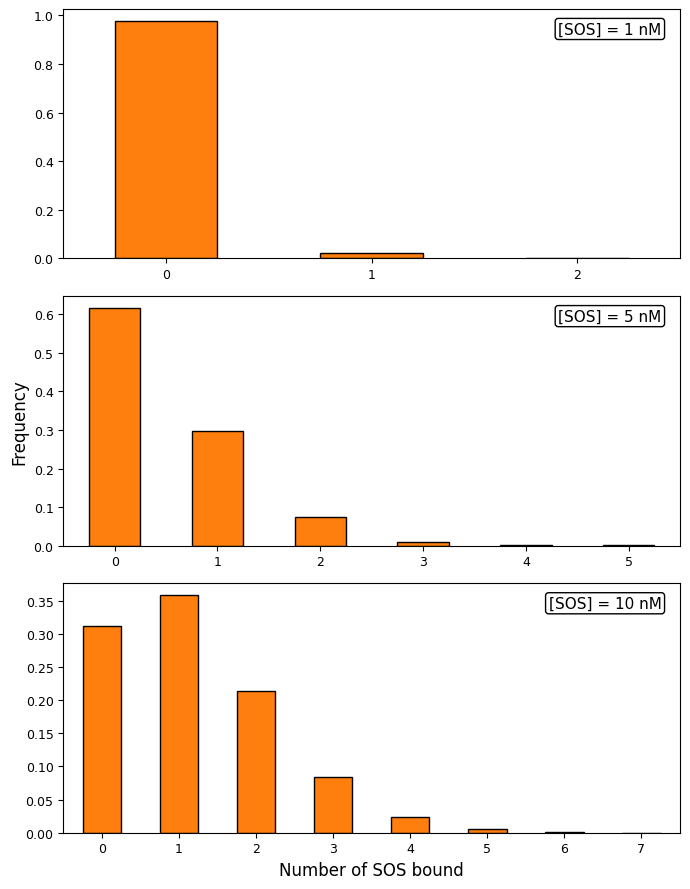

In [41]:
fig, axes = plt.subplots(len(traj), 1, figsize=(7, 3 * len(traj)))
if len(traj) == 1:
    axes = [axes]

for j, (t, sos) in enumerate(zip(traj, pval)):
    ax  = axes[j]
    max_bound = int(np.max(t['totalBoundRas']))
    bins = np.arange(max_bound + 2) - 0.25
    ax.hist(t['totalBoundRas'], bins=bins, density=True,
            color='C1', edgecolor='black', width=0.5, align='mid')
    ax.set_xlim(-0.5, max_bound + 0.5)
    ax.set_xticks(range(max_bound + 1))
    ax.text(0.97, 0.95, f'[SOS] = {sos} nM', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black'))
    ax.tick_params(labelsize=9)
    if j == len(traj) - 1:
        ax.set_xlabel('Number of SOS bound', fontsize=12)
    if j == len(traj) // 2:
        ax.set_ylabel('Frequency', fontsize=12)

plt.tight_layout()

plt.show()


## D — RasGTP conditioned on SOS occupancy

Each color corresponds to different SOS occupancy state n.



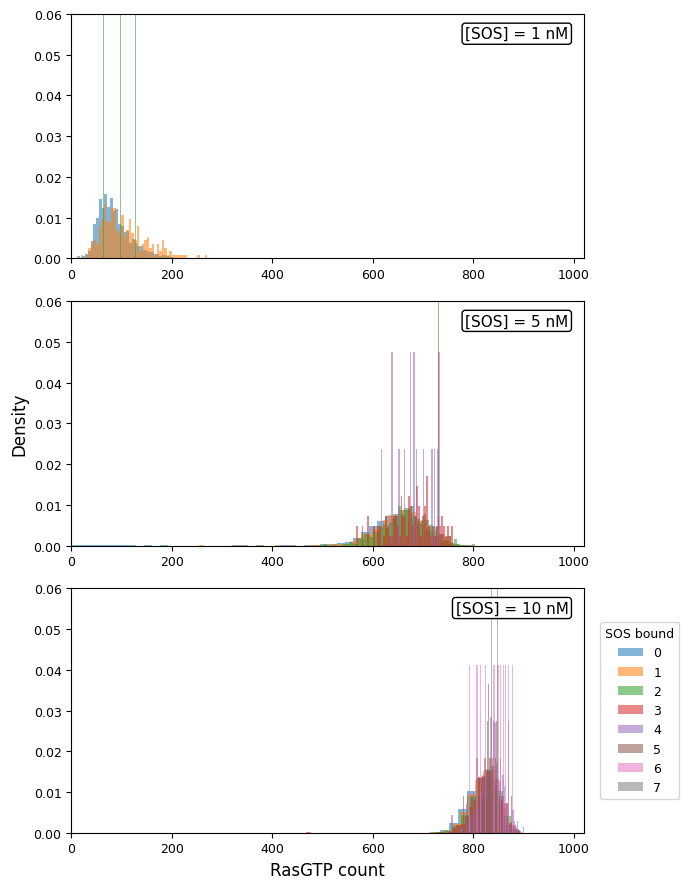

In [42]:
fig, axes = plt.subplots(len(traj), 1, figsize=(7, 3 * len(traj)))
if len(traj) == 1:
    axes = [axes]

for j, (t, sos) in enumerate(zip(traj, pval)):
    ax     = axes[j]
    smax   = int(np.max(t['totalBoundRas']))
    for s in range(smax + 1):
        mask = t['totalBoundRas'] == s
        data = t['totalRasGTP'][mask]
        if data.size > 0:
            ax.hist(data, bins=50, density=True, alpha=0.55,
                    label=str(s), color=color_cycle[s % len(color_cycle)])
    ax.set_xlim(0, 1020)
    ax.set_ylim(0, 0.06)
    ax.text(0.97, 0.95, f'[SOS] = {sos} nM', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black'))
    ax.tick_params(labelsize=9)
    if j == len(traj) - 1:
        ax.set_xlabel('RasGTP count', fontsize=12)
        ax.legend(title='SOS bound', fontsize=9, title_fontsize=9,
                  bbox_to_anchor=(1.02, 0.5), loc='center left')
    if j == len(traj) // 2:
        ax.set_ylabel('Density', fontsize=12)

plt.tight_layout()

plt.show()
